In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import pickle


In [ ]:
# Create a custom colormap that transitions from white to red
cmap = mcolors.LinearSegmentedColormap.from_list("red_gradient", ["white", "red"])


In [214]:
def update_probabilities(student_probs, skill_id, knowledge_matrix, correct):
    """
    Updates the student's knowledge probabilities based on their answer.
    :param student_probs: current skill knowledge probabilities (numpy array)
    :param skill_id: the index of the skill attempted
    :param knowledge_matrix: predefined matrix showing how much each skill influences others
    :param correct: whether the answer was correct (True or False)
    :return: updated probabilities
    """
    if correct:
        diff = knowledge_matrix[skill_id]
    else:
        diff = -1 / 2 * knowledge_matrix[skill_id]
    student_probs += diff

    student_probs = np.clip(student_probs, 0.05, 0.95)

    return student_probs

def generate_student_probs(num_skills=15, alpha=2, beta=2):
    # Generate probabilities using a Beta distribution with alpha and beta
    probs = np.random.beta(alpha, beta, num_skills)
    
    # Clip the values at 0.95 to avoid probabilities larger than 0.95
    probs = np.clip(probs, 0.05, 0.95)
    
    return probs


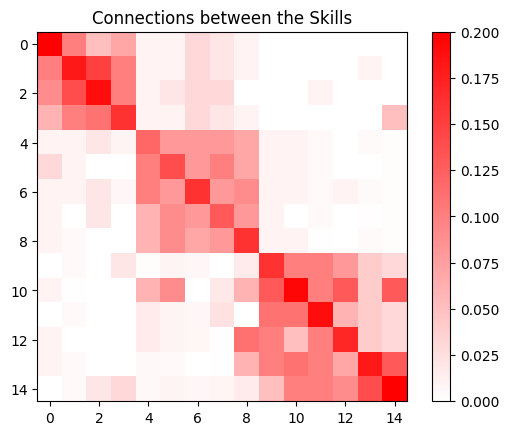

In [265]:
knowledge_matrix = np.array([
    [0.2, 0.1, 0.05, 0.07, 0.01, 0.01, 0.03, 0.02, 0.01, 0, 0, 0, 0, 0, 0],
    [0.1, 0.18, 0.15, 0.10, 0.01, 0.01, 0.03, 0.02, 0.01, 0, 0, 0, 0, 0.01, 0],
    [0.09, 0.14, 0.19, 0.10, 0.01, 0.02, 0.03, 0.03, 0, 0, 0, 0.01, 0, 0, 0],
    [0.06, 0.1, 0.11, 0.16, 0.01, 0.01, 0.03, 0.02, 0.01, 0, 0, 0, 0, 0, 0.05],
    [0.01, 0.01, 0.02, 0.009, 0.12, 0.08, 0.08, 0.08, 0.07, 0.01, 0.01, 0.005, 0, 0.004, 0.003],
    [0.03, 0.01, 0, 0, 0.1, 0.14, 0.08, 0.1, 0.07, 0.01, 0.01, 0.005, 0, 0, 0.003],
    [0.01, 0.01, 0.02, 0.007, 0.1, 0.08, 0.16, 0.08, 0.09, 0.01, 0.01, 0.005, 0.01, 0.004, 0.003],
    [0.01, 0, 0.02, 0, 0.06, 0.09, 0.08, 0.13, 0.08, 0.01, 0, 0.005, 0, 0.002, 0.003],
    [0.01, 0.005, 0.00, 0, 0.06, 0.09, 0.07, 0.08, 0.16, 0.01, 0.01, 0.001, 0, 0.004, 0.003],

    [0, 0.005, 0.00, 0.02, 0.0026, 0.009, 0.007, 0.0, 0.016, 0.16, 0.1, 0.1, 0.08, 0.04, 0.03],
    [0.01, 0.001, 0.00, 0, 0.06, 0.09, 0.0007, 0.018, 0.06, 0.13, 0.195, 0.1, 0.13, 0.04, 0.13],
    [0, 0.005, 0.00, 0, 0.016, 0.009, 0.007, 0.0238, 0, 0.11, 0.11, 0.19, 0.06, 0.04, 0.03],
    [0.01, 0.00, 0.00, 0, 0.016, 0.009, 0.0077, 0.0008, 0.111, 0.1, 0.05, 0.1, 0.17, 0.04, 0.03],
    [0.01, 0.005, 0.00, 0, 0.006, 0.005, 0.0007, 0.0008, 0.06, 0.1, 0.11, 0.1, 0.07, 0.18, 0.13],
    [0, 0.005, 0.02, 0.03, 0.006, 0.009, 0.007, 0.008, 0.016, 0.05, 0.1, 0.1, 0.09, 0.14, 0.2],
    ])

num_skills = knowledge_matrix.shape[0]

# Plot the matrix
plt.imshow(knowledge_matrix, cmap=cmap, interpolation='nearest')
plt.colorbar()  # Adds a color bar to show the value scale
plt.title("Connections between the Skills")
plt.show()

In [286]:
sequences = []

for seq_len in seq_lens:
    student_probs = generate_student_probs(alpha=3, beta=6)
    sequence = []
    for i in range(seq_len):
        skill_id = np.random.randint(0, num_skills)
        correct = 1 if random.random() < student_probs[skill_id] else 0
        sequence.append((skill_id, correct))
        student_probs = update_probabilities(student_probs, skill_id, knowledge_matrix, correct)
    sequences.append(sequence)

    

In [292]:
user_dict = {}
for i, sequence in enumerate(sequences, 1):
    modified_sequence = []
    for skill_id, correct in sequence:
        modified_skill_id = np.zeros(num_skills)
        modified_skill_id[skill_id] = 1.
        modified_sequence.append((modified_skill_id, np.float64(correct)))
    user_dict[i] = modified_sequence

In [293]:
with open("synthetic_data.pkl", "wb") as file:
    pickle.dump(user_dict, file)